# **Train-Test-Split**

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [83]:
df = pd.read_csv('./data/train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [84]:
# Intializing the features and target variable

X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

In [85]:
# Splitting the dataset into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [86]:
# Confirming if stratification was successful

print(y_train.value_counts(normalize=True))
print() 
print(y_val.value_counts(normalize=True))

Loan_Status
Y    0.686354
N    0.313646
Name: proportion, dtype: float64

Loan_Status
Y    0.691057
N    0.308943
Name: proportion, dtype: float64


Stratification is a success. As both train and validation sets have 69-31 distribution.

# **Feature Engineering**

**Feature : income-to-loan** ApplicantIncome by itself is dead and CoapplicantIncome has a signal. 

But, ratio between income-to-loan could have a clear signal as high ratio means they can pay the loan comfortably.

**Formulae :** (ApplicantIncome + CoapplicantIncome) / LoanAmount

In [87]:
# checking if the formula is feasible.

print(f"Null values in denominator: {X_train['LoanAmount'].isnull().sum()}\n")

numerator = X_train['ApplicantIncome'] + X_train['CoapplicantIncome']
print(f"Null values in numerator: {numerator.isnull().sum()}")


Null values in denominator: 20

Null values in numerator: 0


There are null values in the denominator, which we got to impute first. As per eda report 'LoanAmount' is right-skewed so we must use median as impute.

In [88]:
# Imputing missing values in 'LoanAmount' with the median value.

loan_amount_median = X_train['LoanAmount'].median()
X_train['LoanAmount'] = X_train['LoanAmount'].fillna(loan_amount_median)
X_val['LoanAmount'] = X_val['LoanAmount'].fillna(loan_amount_median)

The imputation is lekage safe, as both are filled with x_train medians (no peaking into validation sets)

In [89]:
# Checking if the missing values have been imputed correctly

print(X_train['LoanAmount'].isnull().sum() + X_val['LoanAmount'].isnull().sum()) # expected output: 0

0


Good, the imputation is successful.

In [90]:
# Engineering the new feature 'income_to_loan_ratio'.

X_train['income_to_loan_ratio'] = (X_train['ApplicantIncome'] + X_train['CoapplicantIncome']) / X_train['LoanAmount'] 
X_val['income_to_loan_ratio'] = (X_val['ApplicantIncome'] + X_val['CoapplicantIncome']) / X_val['LoanAmount']

<Axes: ylabel='Loan_Status'>

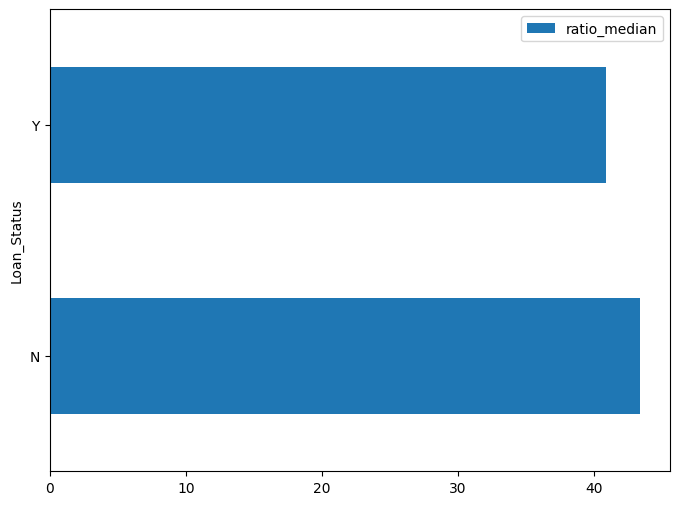

In [91]:
# Hypothesis : 'income_to_loan_ratio' is a good predictor of loan approval.

df_train = pd.concat([X_train, y_train], axis=1)

# Do approved people have different ratio_medians.

df_train.groupby('Loan_Status').agg(
    ratio_median=('income_to_loan_ratio', 'median')
    ).plot(kind='barh', figsize=(8, 6))

There is no signal here.

<Axes: ylabel='income_to_loan_ratio_bin'>

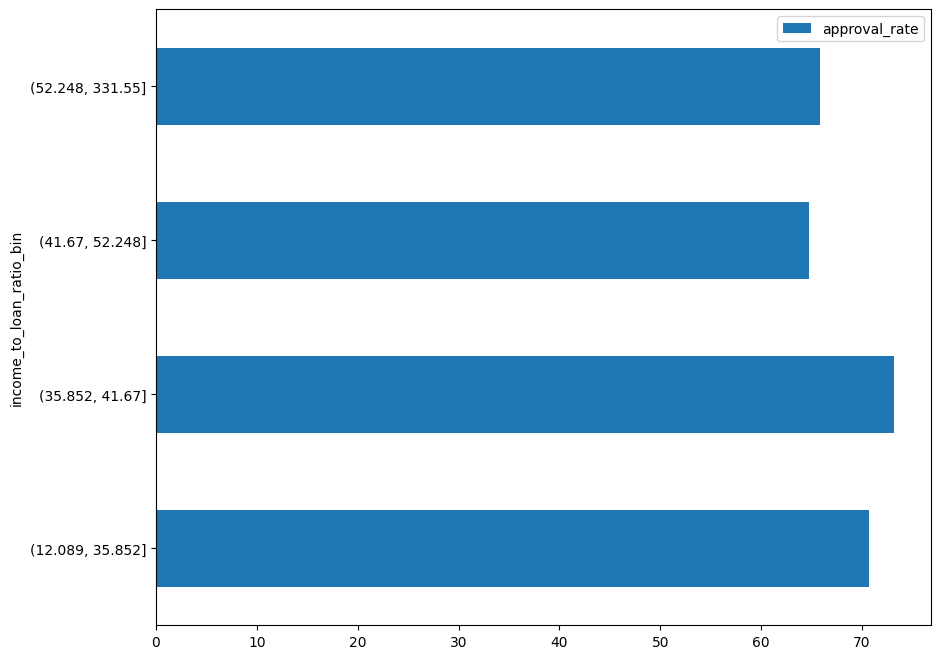

In [92]:
# Do higher income_to_loan_ratio people have higher approval rates?

df_train['income_to_loan_ratio_bin'] = pd.qcut(df_train['income_to_loan_ratio'], 4)
df_train.groupby('income_to_loan_ratio_bin').agg(
    approval_rate=('Loan_Status', lambda x: (x == 'Y').mean()*100)
    ).plot(kind='barh', figsize=(10, 8))

No signal here for sure. The approval rates are non-monotonic.

The possible reason for this would be that 'Credit_History' is dominating so hard that affordability doesn't even matter. 

Make sense, because having the money and paying the money are two different things. 

In [93]:
# Removing the feature 'income_to_loan_ratio'

X_train = X_train.drop('income_to_loan_ratio', axis=1)
X_val = X_val.drop('income_to_loan_ratio', axis=1)